In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
import sys
sys.path.append('.')
from utils import normalise, remove_outliers, flatten

search_result = lk.search_lightcurve("Kepler-452", mission="Kepler", quarter=6)
lc = search_result[0].download()

time = lc.time.value
flux = lc.flux.value
norm_flux = normalise(flux)

/Users/simalnaz/Documents/exoplanet-detector/venv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
# Apply cleaning pipeline
clean_time, clean_flux = remove_outliers(time, norm_flux, sigma=3.0)
flat_flux, trend = flatten(clean_time, clean_flux, window_size=301)

print(f"Original points         : {len(time)}")
print(f"After outlier removal   : {len(clean_time)}")
print(f"Outliers removed        : {len(time) - len(clean_time)}")
print(f"\nFlux std before flatten : {np.std(clean_flux):.6f}")
print(f"Flux std after flatten  : {np.std(flat_flux):.6f}")

Removed — outliers ( ———% of data)
Original points         : 4276
After outlier removal   : 4267
Outliers removed        : 9

Flux std before flatten : 0.000143
Flux std after flatten  : 0.000134


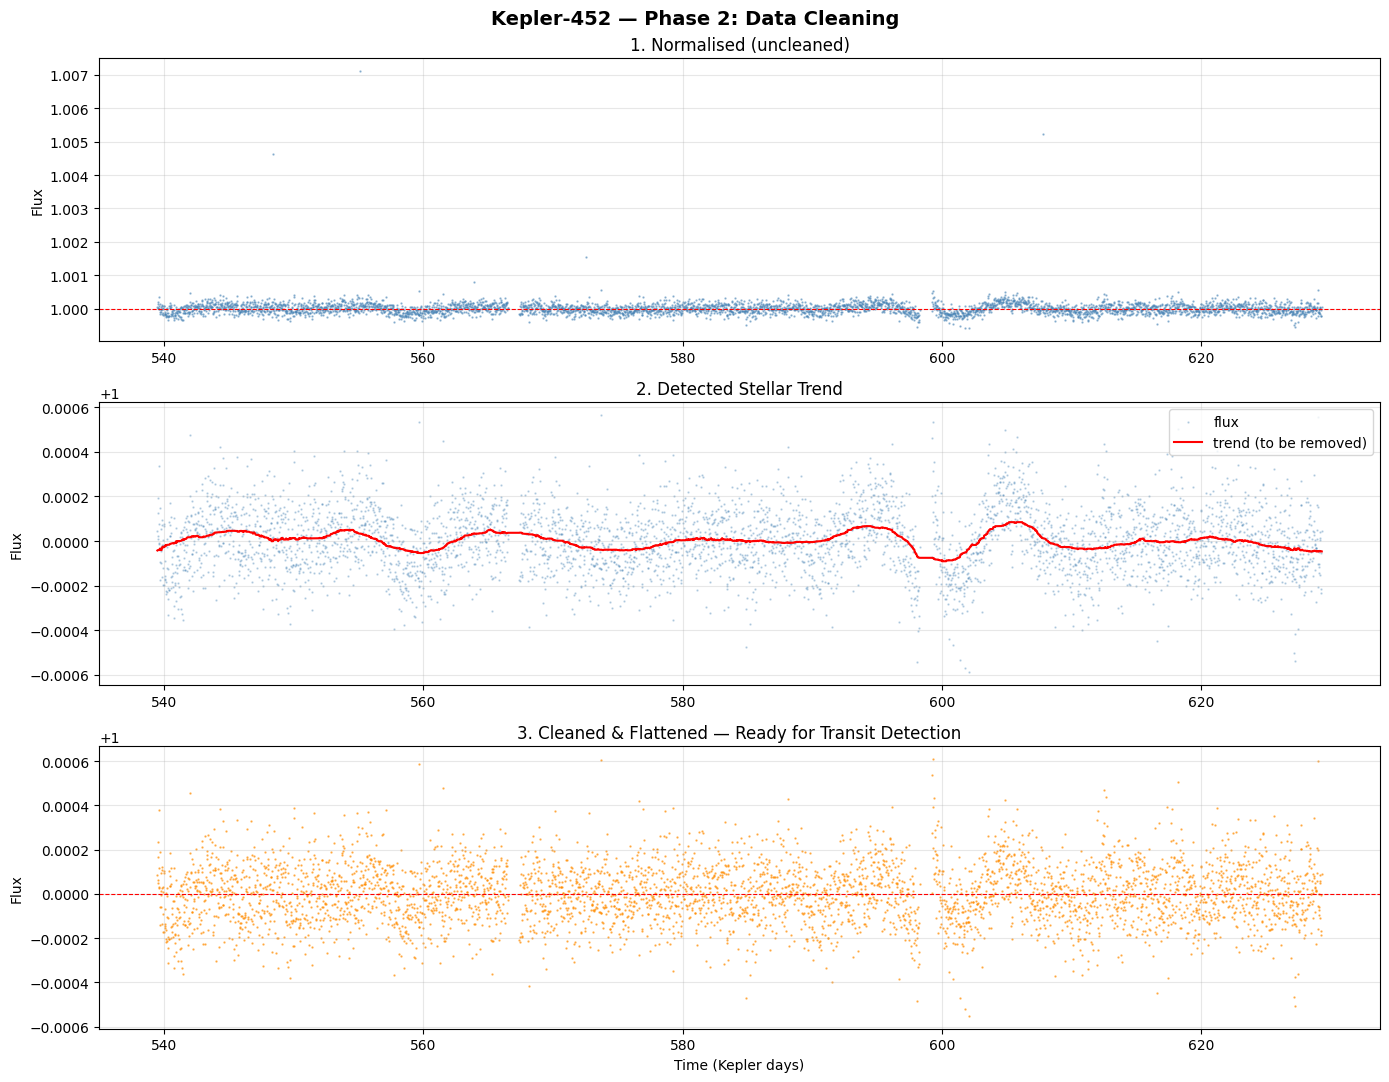

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Plot 1 - normalised raw
axes[0].scatter(time, norm_flux, s=0.5, color='steelblue', alpha=0.5)
axes[0].set_title('1. Normalised (uncleaned)', fontsize=12)
axes[0].set_ylabel('Flux')
axes[0].axhline(1.0, color='red', linewidth=0.8, linestyle='--')
axes[0].grid(True, alpha=0.3)

# Plot 2 - trend overlay
axes[1].scatter(clean_time, clean_flux, s=0.5, color='steelblue', alpha=0.3, label='flux')
axes[1].plot(clean_time, trend, color='red', linewidth=1.5, label='trend (to be removed)')
axes[1].set_title('2. Detected Stellar Trend', fontsize=12)
axes[1].set_ylabel('Flux')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Plot 3 - flattened
axes[2].scatter(clean_time, flat_flux, s=0.5, color='darkorange', alpha=0.6)
axes[2].set_title('3. Cleaned & Flattened — Ready for Transit Detection', fontsize=12)
axes[2].set_xlabel('Time (Kepler days)')
axes[2].set_ylabel('Flux')
axes[2].axhline(1.0, color='red', linewidth=0.8, linestyle='--')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Kepler-452 — Phase 2: Data Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()